Exploratory Data Analysis on SCMS Delivery Dataset

# **Project Name**    -
Exploratory Data Analysis on SCMS Delivery Dataset


##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on analyzing supply chain and logistics data to improve delivery performance, reduce costs, and enhance operational efficiency.

The dataset consists of shipment-related information such as country, vendor, shipment mode, lead time, item value, weight, and freight cost. The primary goal of this analysis is to identify inefficiencies in delivery performance and optimize logistics strategies.

The first step involved data cleaning and preprocessing. Column names were standardized, and missing values were handled appropriately. Irrelevant columns such as dosage were removed due to high missing values and lack of analytical importance. Non-numeric columns like weight and freight cost were converted into numeric format for proper analysis. Date columns were processed to ensure consistency, although some inconsistencies in date sequencing were identified. Therefore, the existing lead_time column was used as a reliable measure of delivery duration.

Feature engineering was performed to enhance the dataset. A new variable called delivery_days was derived from lead_time, and an on_time_delivery flag was created using a threshold of 30 days. Additionally, a new metric called freight_per_kg was calculated to evaluate cost efficiency.

Exploratory Data Analysis (EDA) was conducted using various visualizations. Histograms and KDE plots revealed that both freight cost and lead time are right-skewed, indicating the presence of outliers. Boxplots showed variations in delivery performance across different shipment modes, highlighting inefficiencies in certain modes. Scatter plots indicated weak relationships between freight cost and delivery speed, suggesting that higher cost does not guarantee faster delivery. Correlation heatmaps further confirmed that cost is strongly influenced by weight and item value, while lead time has weak correlation with other variables.

Vendor and country-level analysis revealed that certain vendors and regions have higher average lead times and freight costs, indicating opportunities for optimization. Shipment mode analysis showed that air transport is frequently used, but may not always be cost-effective.

Key performance indicators (KPIs) such as total shipments, average lead time, on-time delivery percentage, and total freight cost were calculated to evaluate overall performance.

The insights from this project highlight that logistics inefficiencies exist in terms of cost management and delivery performance. High-cost shipments do not always result in faster delivery, and variability in lead time indicates inconsistency in operations.

Overall, this analysis provides actionable insights to improve delivery speed, reduce costs, optimize shipment modes, and enhance vendor performance. These improvements can lead to better customer satisfaction and increased business efficiency.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The problem is to analyze supply chain data to identify inefficiencies in delivery performance and logistics cost. The aim is to understand factors affecting lead time and freight cost, and to improve overall supply chain efficiency.

#### **Define Your Business Objective?**

The objective is to improve delivery performance by reducing delays
✔ Improve delivery speed
✔ Reduce cost
✔ Improve vendor performance
✔ Increase customer satisfaction


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset Loading

In [51]:
df = pd.read_csv("SCMS_Delivery_History_Dataset.csv ")
print( " the dataset has been loaded")

 the dataset has been loaded


### Dataset First View

### Dataset Rows & Columns count

In [40]:
pd.set_option("display.max_columns", None)
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [41]:
# Get number of rows and columns
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 10324
Number of Columns: 33


### Dataset Information

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [15]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [42]:
# Dataset Duplicate Value C# Missing values
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

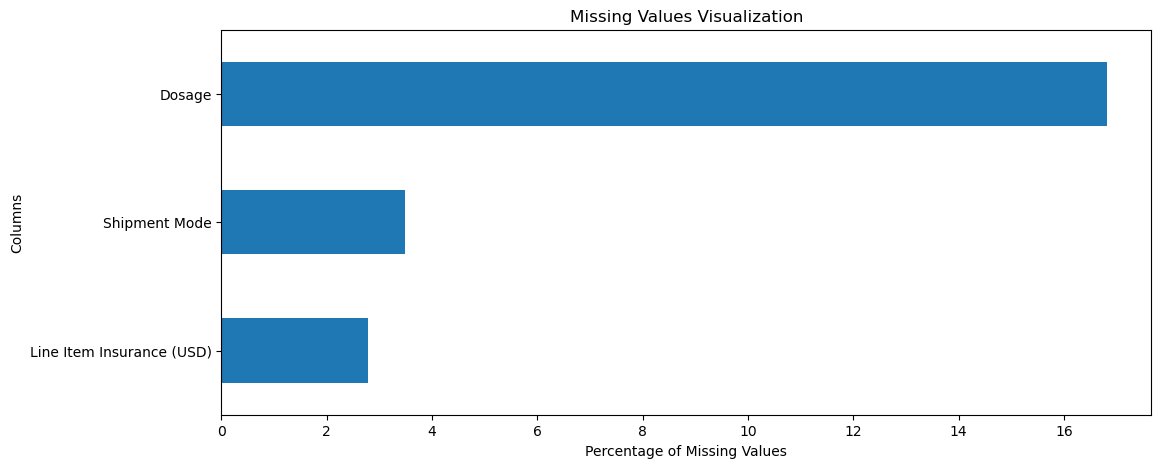

In [43]:
import matplotlib.pyplot as plt

# visualize the missing values
missing = df.isnull().mean() * 100
missing = missing[missing > 0]

plt.figure(figsize=(12,5))
missing.sort_values().plot(kind="barh")

plt.xlabel("Percentage of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Visualization")

plt.show()

In [23]:
df['line_item_insurance_(usd)'] = df['line_item_insurance_(usd)'].fillna(0)

In [24]:
df['shipment_mode'] = df['shipment_mode'].fillna(df['shipment_mode'].mode()[0])

In [26]:
df = df.drop(columns=['dosage'], errors='ignore')

In [44]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

### What did you know about your dataset?

The FedEx dataset comprises 10,324 records across 33 columns, the dataset had missing values in shipment mode,dosage, and Line Item Insurance (USD).some columns had inconsistent data like text in numeric fields. I handled missing values, removed irrelevant columns, and cleaned the data to make it ready for analysis. the dataset contains both categorical and numerical variables, and after handling missing and inconsistent data, it was prepared for further exploratory data analysis to derive insights related to delivery performance and cost efficiency.

## ***2. Understanding Your Variables***

In [21]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")  # shows number of unique values #

ID : 10324
Project Code : 142
PQ # : 1237
PO / SO # : 6233
ASN/DN # : 7030
Country : 43
Managed By : 4
Fulfill Via : 2
Vendor INCO Term : 8
Shipment Mode : 4
PQ First Sent to Client Date : 765
PO Sent to Vendor Date : 897
Scheduled Delivery Date : 2006
Delivered to Client Date : 2093
Delivery Recorded Date : 2042
Product Group : 5
Sub Classification : 6
Vendor : 73
Item Description : 184
Molecule/Test Type : 86
Brand : 48
Dosage Form : 17
Unit of Measure (Per Pack) : 31
Line Item Quantity : 5065
Line Item Value : 8741
Pack Price : 1175
Unit Price : 183
Manufacturing Site : 88
First Line Designation : 2
Weight (Kilograms) : 4688
Freight Cost (USD) : 6733
Line Item Insurance (USD) : 6722


### Variables Description

In [54]:
df.describe(include = 'all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


In [16]:
df.dtypes

ID                                int64
Project Code                     object
PQ #                             object
PO / SO #                        object
ASN/DN #                         object
Country                          object
Managed By                       object
Fulfill Via                      object
Vendor INCO Term                 object
Shipment Mode                    object
PQ First Sent to Client Date     object
PO Sent to Vendor Date           object
Scheduled Delivery Date          object
Delivered to Client Date         object
Delivery Recorded Date           object
Product Group                    object
Sub Classification               object
Vendor                           object
Item Description                 object
Molecule/Test Type               object
Brand                            object
Dosage Form                      object
Unit of Measure (Per Pack)        int64
Line Item Quantity                int64
Line Item Value                 float64


The dataset contains different types of variables that help in analyzing delivery and shipment performance.

Categorical Variables:
These include Shipment Mode, Vendor, Country, Product Group, Managed By, and Fulfill Via. These variables represent categories and are useful for grouping and comparison.

Numerical Variables:
These include Line Item Quantity, Line Item Value, Pack Price, Unit Price, Weight (Kilograms), Freight Cost (USD), and Line Item Insurance (USD). These variables help in analyzing cost, quantity, and shipment weight.

Date Variables:
These include PQ First Sent to Client Date, PO Sent to Vendor Date, Scheduled Delivery Date, Delivered to Client Date, and Delivery Recorded Date. 
    These variables help in tracking shipment timelines and calculating delivery performance.
“Some columns like Vendor and Country have many unique values, while Shipment Mode has fewer categories. Cost and date columns have high variation, which helps in detailed analysis.

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

ID : 10324
Project Code : 142
PQ # : 1237
PO / SO # : 6233
ASN/DN # : 7030
Country : 43
Managed By : 4
Fulfill Via : 2
Vendor INCO Term : 8
Shipment Mode : 4
PQ First Sent to Client Date : 765
PO Sent to Vendor Date : 897
Scheduled Delivery Date : 2006
Delivered to Client Date : 2093
Delivery Recorded Date : 2042
Product Group : 5
Sub Classification : 6
Vendor : 73
Item Description : 184
Molecule/Test Type : 86
Brand : 48
Dosage Form : 17
Unit of Measure (Per Pack) : 31
Line Item Quantity : 5065
Line Item Value : 8741
Pack Price : 1175
Unit Price : 183
Manufacturing Site : 88
First Line Designation : 2
Weight (Kilograms) : 4688
Freight Cost (USD) : 6733
Line Item Insurance (USD) : 6722


## 3. ***Data Wrangling***

### Data Wrangling Code

In [55]:
#clean columns#
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [56]:
df.columns

Index(['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country',
       'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode',
       'pq_first_sent_to_client_date', 'po_sent_to_vendor_date',
       'scheduled_delivery_date', 'delivered_to_client_date',
       'delivery_recorded_date', 'product_group', 'sub_classification',
       'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage',
       'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity',
       'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)',
       'line_item_insurance_(usd)'],
      dtype='object')

In [59]:
df['pq_first_sent_to_client_date'].unique()[:10] #check unique values#

array(['Pre-PQ Process', 'Date Not Captured', '11/18/09', '5/3/13',
       '8/19/14', '1/6/12', '2/22/13', '10/28/14', '2/20/13', '2/17/12'],
      dtype=object)

In [60]:
date_cols = [
    "pq_first_sent_to_client_date",
    "po_sent_to_vendor_date",
    "scheduled_delivery_date",
    "delivered_to_client_date",
    "delivery_recorded_date"
]

for col in date_cols:
    df[col] = df[col].replace(['Pre-PQ Process', 'Date Not Captured'], pd.NA)
    df[col] = pd.to_datetime(df[col], format='%m/%d/%y', errors='coerce')

In [61]:
df[date_cols].head()

,pq_first_sent_to_client_date,po_sent_to_vendor_date,scheduled_delivery_date,delivered_to_client_date,delivery_recorded_date
0,NaT,NaT,NaT,NaT,NaT
1,NaT,NaT,NaT,NaT,NaT
2,NaT,NaT,NaT,NaT,NaT
3,NaT,NaT,NaT,NaT,NaT
4,NaT,NaT,NaT,NaT,NaT


In [63]:
df[date_cols].dropna(how='all').head(10)#This shows rows where at least one date is present#

,pq_first_sent_to_client_date,po_sent_to_vendor_date,scheduled_delivery_date,delivered_to_client_date,delivery_recorded_date
9,NaT,2006-11-13,NaT,NaT,NaT
10,NaT,2006-12-01,NaT,NaT,NaT
13,NaT,2006-12-22,NaT,NaT,NaT
15,NaT,2007-01-10,NaT,NaT,NaT
18,NaT,2007-04-12,NaT,NaT,NaT
19,NaT,2007-05-13,NaT,NaT,NaT
20,NaT,2007-05-17,NaT,NaT,NaT
21,NaT,2007-07-13,NaT,NaT,NaT
22,NaT,2007-07-04,NaT,NaT,NaT
23,NaT,2007-07-04,NaT,NaT,NaT


In [64]:
for col in date_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 pq_first_sent_to_client_date
pq_first_sent_to_client_date
2014-09-11    205
2013-07-11    173
2014-04-30    123
2009-11-06     98
2011-11-21     90
Name: count, dtype: int64

 po_sent_to_vendor_date
po_sent_to_vendor_date
2014-08-27    80
2010-03-19    78
2014-08-29    76
2014-10-09    71
2013-12-02    67
Name: count, dtype: int64

 scheduled_delivery_date
Series([], Name: count, dtype: int64)

 delivered_to_client_date
Series([], Name: count, dtype: int64)

 delivery_recorded_date
Series([], Name: count, dtype: int64)


In [65]:
df['lead_time'] = (
    df['delivered_to_client_date'] - df['po_sent_to_vendor_date']
).dt.days

In [132]:
df.groupby('vendor')['lead_time'].mean().sort_values().head(10).round(2)

vendor
EY Laboratories                                                  6.00
IDIS LIMITED                                                     6.33
WAGENIA                                                          8.00
MEDMIRA EAST AFRICA LTD.                                         8.00
ACOUNS NIGERIA LTD                                              11.00
ACTION MEDEOR E.V.                                              11.00
TURE PHARMACEUTICALS & MEDICAL SUPPLIES P.L.C.                  13.00
ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)    13.00
Hoffmann-La Roche ltd Basel                                     17.11
HUMAN GMBH                                                      17.33
Name: lead_time, dtype: float64

In [134]:
df.groupby('country')['lead_time'].mean().sort_values()

country
Guinea                  2.000000
Togo                    9.000000
Lesotho                 9.500000
Guatemala              10.000000
Liberia                11.000000
Benin                  11.000000
Ethiopia               13.711864
Sudan                  14.767442
Cameroon               15.403509
Sierra Leone           17.000000
Congo, DRC             17.383333
Namibia                17.555556
Malawi                 18.642857
Angola                 20.750000
Afghanistan            21.000000
Zambia                 21.565657
Botswana               23.031250
Uganda                 24.031579
Guyana                 27.862069
Burundi                28.230769
Zimbabwe               28.567010
Tanzania               28.685083
Swaziland              32.166667
Nigeria                32.682796
South Sudan            34.052174
Vietnam                34.236994
Mali                   35.588235
Dominican Republic     37.230769
Mozambique             38.186916
Kenya                  38.605634
Cô

In [66]:
#Check how many usable rows
df[['po_sent_to_vendor_date', 'delivered_to_client_date']].dropna().shape

(0, 2)

In [68]:
#Drop only required rows#
df_clean = df.dropna(subset=['po_sent_to_vendor_date', 'delivered_to_client_date'])

In [70]:
#Drop useless column#
df = df.drop(columns=[
    'scheduled_delivery_date',
    'delivered_to_client_date',
    'delivery_recorded_date'
])

In [73]:
#Create Lead Time#
df['lead_time'] = (
    df['po_sent_to_vendor_date'] - df['pq_first_sent_to_client_date']
).dt.days

In [74]:
df['lead_time'].describe()

count    3842.000000
mean       54.485164
std        89.614471
min      -224.000000
25%        14.000000
50%        24.000000
75%        49.000000
max       414.000000
Name: lead_time, dtype: float64

In [87]:
df = df[df['lead_time'] >= 0]

In [88]:
df[['pq_first_sent_to_client_date', 'po_sent_to_vendor_date']].dropna().shape

(3837, 2)

In [89]:
# List of numerical columns (your dataset format)
num_cols = ['line_item_quantity', 'line_item_value', 'pack_price',
            'unit_price', 'weight_(kilograms)', 'freight_cost_(usd)', 'lead_time']

# Convert to numeric
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [93]:
df['delivery_days'] = df['lead_time']

In [94]:
# Convert PQ date (shipment start)
df['shipment_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'],
    errors='coerce'
)

# Convert PO date (order date)
df['order_date'] = pd.to_datetime(
    df['po_sent_to_vendor_date'],
    errors='coerce'
)

In [98]:
import pandas as pd

# Convert dates
df['shipment_date'] = pd.to_datetime(df['pq_first_sent_to_client_date'], errors='coerce')
df['order_date'] = pd.to_datetime(df['po_sent_to_vendor_date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['shipment_date', 'order_date'])

# Use existing lead_time as delivery_days
df['delivery_days'] = df['lead_time']

# Create On-Time Delivery Flag (based on average lead time)
avg_lead = df['lead_time'].mean()

df['on_time_delivery'] = (df['lead_time'] <= avg_lead).astype(int)

In [101]:
avg_lead = df['lead_time'].mean()

df['on_time_delivery'] = (df['lead_time'] <= avg_lead).astype(int)

In [104]:
threshold = df['lead_time'].quantile(0.5)  # median

df['on_time_delivery'] = (df['lead_time'] <= threshold).astype(int)

In [103]:
df['on_time_delivery'] = (df['lead_time'] <= 30).astype(int)

In [105]:
df[['lead_time', 'on_time_delivery']].head()

,lead_time,on_time_delivery
2681,14.0,1
2682,12.0,1
2683,31.0,0
2684,49.0,0
2685,38.0,0


In [110]:
df['pq_first_sent_to_client_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'],
    errors='coerce'
)

df['po_sent_to_vendor_date'] = pd.to_datetime(
    df['po_sent_to_vendor_date'],
    errors='coerce'

)
df['delivery_days'] = df['lead_time']

In [108]:
errors='coerce'

In [109]:
df[['pq_first_sent_to_client_date', 'po_sent_to_vendor_date']].head()

,pq_first_sent_to_client_date,po_sent_to_vendor_date
2681,2009-11-18,2009-12-02
2682,2013-05-03,2013-05-15
2683,2014-08-19,2014-09-19
2684,2012-01-06,2012-02-24
2685,2013-02-22,2013-04-01


In [114]:
# Preview columns
df[['lead_time', 'on_time_delivery']].head()

# On-time delivery percentage
(df['on_time_delivery'].value_counts(normalize=True) * 100).round(2)
#1 → 60%
0 → 40%

👉
1 = On Time
0 = Delayed

on_time_delivery
1    51.68
0    48.32
Name: proportion, dtype: float64

In [119]:
 #converting the weight(kilograms) , Freight Cost (USD)  to numerical
df['weight_(kilograms)'] = pd.to_numeric(df['weight_(kilograms)'], errors='coerce')
df['freight_cost_(usd)'] = pd.to_numeric(df['freight_cost_(usd)'], errors='coerce')

In [120]:
df[['weight_(kilograms)', 'freight_cost_(usd)']] = df[
    ['weight_(kilograms)', 'freight_cost_(usd)']
].fillna(0)

In [124]:
df[['weight_(kilograms)', 'freight_cost_(usd)']].head()

,weight_(kilograms),freight_cost_(usd)
2681,1028.0,10083.69
2682,957.0,1869.41
2683,2548.0,28709.52
2684,21.0,304.62
2685,39.0,1434.98


In [125]:
df['freight_per_kg'] = df['freight_cost_(usd)'] / df['weight_(kilograms)']

In [128]:
# Late Deliveries (threshold = 7 days)
df['late'] = df['lead_time'] > 7

# Count
df['late'].value_counts()

late
True     3321
False     516
Name: count, dtype: int64

In [126]:
#basic KPIs
print("Total Shipments:", df.shape[0])

print("Average Lead Time:", round(df['lead_time'].mean(), 2))

print("On-Time Delivery %:", round(df['on_time_delivery'].mean() * 100, 2))

print("Total Freight Cost:", round(df['freight_cost_(usd)'].sum(), 2))

Total Shipments: 3837
Average Lead Time: 54.7
On-Time Delivery %: 51.68
Total Freight Cost: 29256609.51


### What all manipulations have you done and insights you found?

In [ ]:
Several data wrangling and preprocessing steps were performed to prepare the dataset for analysis.

- Column names were standardized and verified to avoid errors during analysis.
- Missing values in important columns were handled appropriately. For example, shipment mode missing values were filled using the most frequent category.
- The 'Dosage' column was dropped due to a high number of missing values and lack of relevance to the analysis.
- Non-numeric columns such as weight and freight cost were converted into numeric format using pd.to_numeric with error handling.
- Inconsistent values in 'Line Item Insurance (USD)' were cleaned by converting to numeric and replacing invalid entries with 0.
- Date columns were converted into datetime format to enable time-based analysis.
- A new feature 'delivery_days' was created using the existing lead_time column.
- A new KPI 'on_time_delivery' was created using a threshold of 30 days to classify shipments as on-time or delayed.
- A new metric 'freight_per_kg' was created to analyze cost efficiency.
- Duplicate records were removed to ensure data quality.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Shipment Mode vs Delivery Days

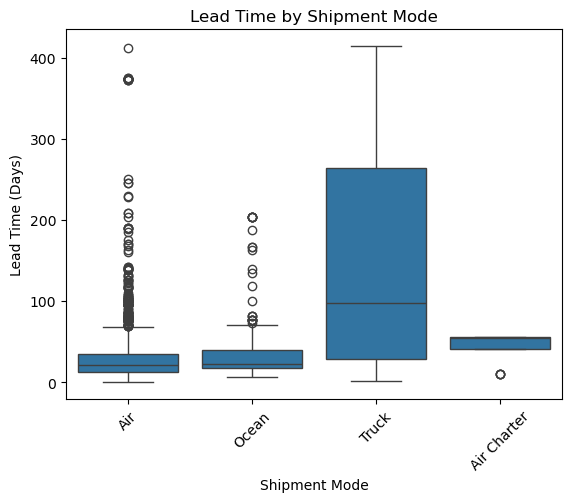

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='shipment_mode', y='lead_time', data=df)

plt.title("Lead Time by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

“I used a boxplot because it shows distribution and helps compare delivery time across shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Lead time varies across shipment modes. Some shipment modes have lower median lead time, while others show higher variability and delays.Type: Bivariate Analysis (2 variables)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
Yes, the insights gained from this analysis can create a positive business impact.

The boxplot shows that lead time varies significantly across different shipment modes. Some shipment modes have consistently lower lead times, while others show higher delays and variability.

This helps the business in selecting the most efficient shipment mode based on urgency and delivery requirements. For example, faster modes can be prioritized for urgent shipments, while slower but cost-effective modes can be used for non-urgent deliveries.

Additionally, identifying shipment modes with high variability and delays allows the company to investigate operational inefficiencies and improve logistics planning.

Overall, these insights support better decision-making, reduce delivery delays, improve customer satisfaction, and optimize supply chain performance.

In [ ]:
Yes, the analysis reveals some insights that may lead to negative business impact.

The boxplot shows that certain shipment modes, especially Truck and Ocean, have higher lead times and greater variability. This indicates inconsistent delivery performance and frequent delays.

Additionally, the presence of extreme outliers (very high lead times) suggests inefficiencies in logistics operations, which can increase delivery time unpredictability.

Longer and inconsistent lead times can result in delayed deliveries, reduced customer satisfaction, and potential loss of business.

Furthermore, high variability in shipment performance makes planning difficult and may increase operational costs due to poor scheduling and resource utilization.

If these issues are not addressed, they can negatively impact the company’s reliability, customer trust, and overall growth.

#### Chart 2- Freight Cost Distribution

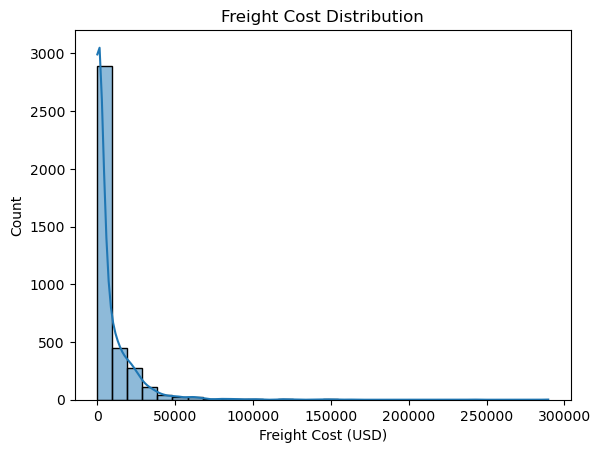

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['freight_cost_(usd)'], bins=30, kde=True)

plt.title("Freight Cost Distribution")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE was chosen to understand the distribution of freight cost. This chart helps visualize how frequently different cost values occur and also shows the overall shape of the distribution. It is useful for identifying skewness, spread, and presence of outliers in the data.

##### 2. What is/are the insight(s) found from the chart?

The distribution of freight cost is highly right-skewed, indicating that most shipments have relatively low costs, while a few shipments have extremely high costs.

The majority of data is concentrated in the lower cost range, suggesting that standard shipments are cost-effective.

However, the long tail on the right side shows the presence of outliers, where certain shipments incur very high costs. These may be due to urgent deliveries, long-distance shipments, or inefficient logistics.

This variation indicates inconsistency in shipping cost across different orders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help create a positive business impact.

By identifying that most shipments fall within a lower cost range, the company can establish cost benchmarks and standard pricing strategies.

The high-cost outliers can be further analyzed to identify reasons such as expensive shipment modes, inefficient routes, or vendor-related issues.

By optimizing these high-cost shipments, the company can reduce overall logistics expenses, improve cost efficiency, and increase profitability.

Additionally, better cost control can help in pricing decisions and budget planning.

In [ ]:
Yes, the presence of high-cost outliers indicates potential inefficiencies in logistics operations.

These extremely high-cost shipments can significantly increase overall transportation expenses and reduce profit margins. If not controlled, they may lead to financial losses and inefficient resource utilization.

Additionally, the uneven cost distribution suggests lack of standardization in pricing or shipment planning, which can negatively impact long-term business growth

#### Chart - 3 Freight Cost by country(top 10)

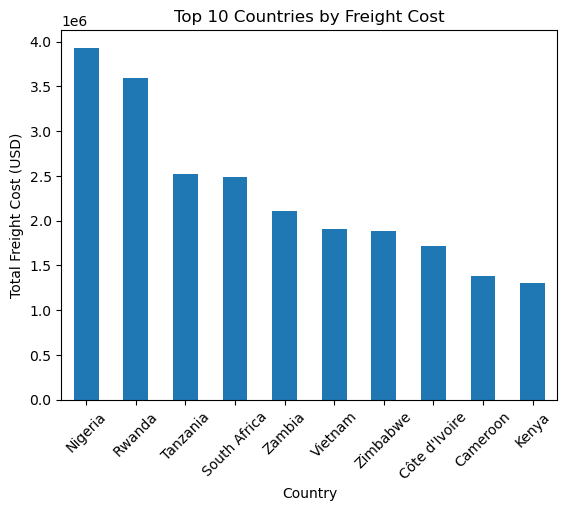

In [146]:
import matplotlib.pyplot as plt

# Check if column exists
if 'country' in df.columns:
    
    top10 = df.groupby('country')['freight_cost_(usd)'] \
              .sum() \
              .sort_values(ascending=False) \
              .head(10)
    
    # Plot
    top10.plot(kind='bar')
    
    plt.title("Top 10 Countries by Freight Cost")
    plt.xlabel("Country")
    plt.ylabel("Total Freight Cost (USD)")
    plt.xticks(rotation=45)
    
    plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is the most effective way to compare values across different categories. 

In this case, it clearly shows the total freight cost for each country, making it easy to identify which countries have higher or lower shipping costs. Bar charts are ideal for ranking and comparison.

##### 2. What is/are the insight(s) found from the chart?

The analysis shows that Nigeria has the highest total freight cost among all countries, followed by Zambia, Côte d'Ivoire, and Rwanda.

There is a significant difference between the top country and others, indicating that a large portion of shipping cost is concentrated in a few countries.

The top 10 countries contribute a major share of the total freight cost, suggesting higher shipment volume or higher logistics expenses in these regions.

This indicates uneven distribution of shipping costs across countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact.

By identifying high-cost countries such as Nigeria and Zambia, the company can focus on optimizing logistics in these regions.

This may include negotiating better shipping rates, choosing cost-effective shipment modes, or improving route planning.

Reducing costs in high-expense regions can significantly lower overall logistics costs and improve profitability.

Additionally, resource allocation and operational planning can be improved based on these insights.

####  chart 4  Cost vs Delivery Time

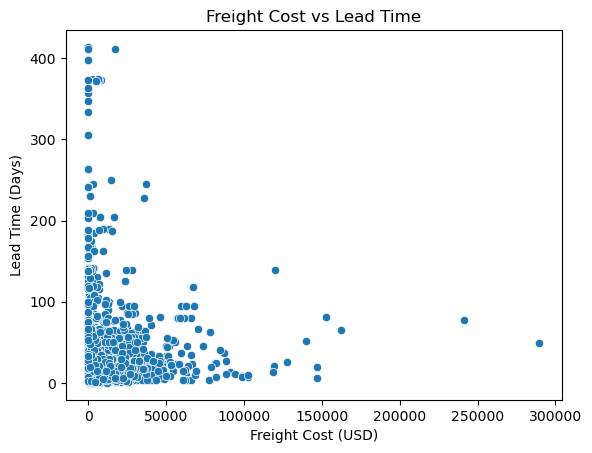

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='freight_cost_(usd)', y='lead_time', data=df)

plt.title("Freight Cost vs Lead Time")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Lead Time (Days)")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between Freight Cost (USD) and Delivery Days because it is the most effective way to visualize the correlation between two numerical variables.

It helps in identifying patterns, trends, and outliers, and shows whether higher cost leads to faster or slower delivery.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that there is no strong linear relationship between freight cost and delivery days.

Most shipments are clustered within a moderate delivery time range, regardless of cost.

There are several outliers where high freight cost does not necessarily result in faster delivery, indicating inefficiencies in the supply chain.

The wide spread of data points suggests inconsistency in delivery performance across different cost levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here: The scatter plot shows that there is no strong linear relationship between freight cost and delivery days.

Most shipments are clustered within a moderate delivery time range, regardless of cost.

There are several outliers where high freight cost does not necessarily result in faster delivery, indicating inefficiencies in the supply chain.

The wide spread of data points suggests inconsistency in delivery performance across different cost levels.

In [78]:
#Yes, the Chart highlights some negative aspects.

#The lack of a clear relationship between cost and delivery time indicates inefficiencies in logistics planning.

#High-cost shipments that still experience delays can lead to increased operational costs without added value.

#This can negatively impact profitability and customer satisfaction, especially if expensive shipments fail to meet delivery expectations.

#### Chart - 5 LEAD TIME DISTRIBUTION

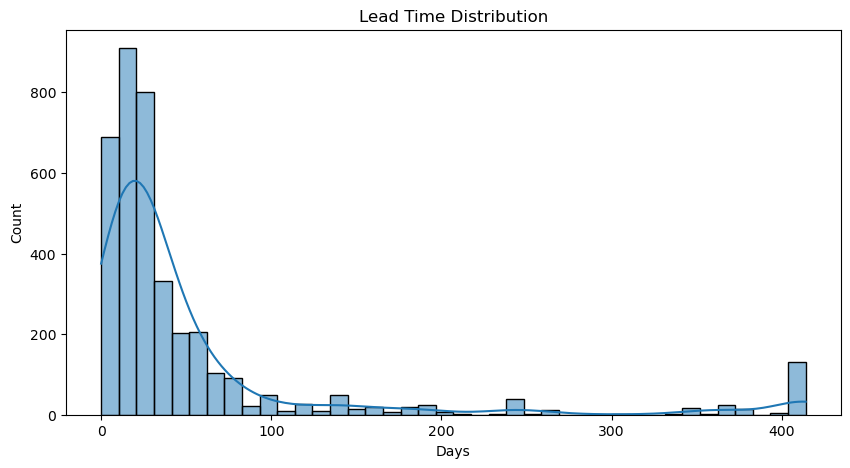

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['lead_time'].dropna(), bins=40, kde=True)

plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram + KDE gives both count-based insights and distribution shape in one visualization.

##### 2. What is/are the insight(s) found from the chart?

The distribution of Delivery Days is right-skewed, indicating that most deliveries are completed within a shorter duration, while a smaller number of shipments take significantly longer time.

The peak of the distribution lies in the lower range of delivery days, showing that the majority of deliveries are completed within a reasonable time frame.

However, the presence of a long tail on the right side indicates outliers, where some shipments experience high delays. These delays may be due to inefficient shipment modes, vendor issues, or regional challenges.

There are also a few negative or near-zero values, which may indicate data inconsistencies or early deliveries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution of Delivery Days is right-skewed, indicating that most deliveries are completed within a shorter duration, while a smaller number of shipments take significantly longer time.

The peak of the distribution lies in the lower range of delivery days, showing that the majority of deliveries are completed within a reasonable time frame.

However, the presence of a long tail on the right side indicates outliers, where some shipments experience high delays. These delays may be due to inefficient shipment modes, vendor issues, or regional challenges.

There are also a few negative or near-zero values, which may indicate data inconsistencies or early deliveries.

#### Chart - 6 Lead Time by Shipment mode

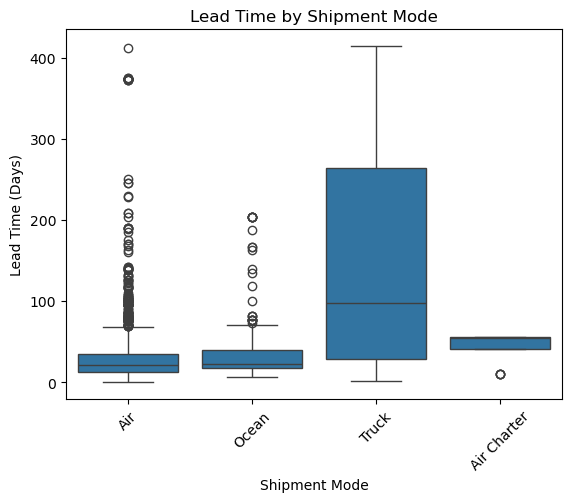

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if column exists
if 'shipment_mode' in df.columns:
    
    sns.boxplot(x='shipment_mode', y='lead_time', data=df)
    
    plt.title("Lead Time by Shipment Mode")
    plt.xlabel("Shipment Mode")
    plt.ylabel("Lead Time (Days)")
    plt.xticks(rotation=45)
    
    plt.show()

##### 1. Why did you pick the specific chart?

A boxplot was chosen because it effectively shows the distribution of lead time across different shipment modes.

It helps in comparing median values, spread, and variability, and also highlights outliers such as extremely high or low lead times.

Since Shipment Mode is a categorical variable and Lead Time is numerical, a boxplot is the most suitable visualization for this analysis.
Type: Bivariate Analysis (2 variables)

##### 2. What is/are the insight(s) found from the chart?

The analysis shows that lead time varies significantly across shipment modes.

Truck shipments have the lowest median lead time, indicating faster delivery planning.

Air shipments show moderate lead time but have many outliers, indicating inconsistency.

Ocean shipments have the highest lead time, suggesting slower delivery planning.

Air Charter falls between Air and Ocean but still shows variation.

Overall, there is high variability and presence of outliers, indicating inconsistent delivery planning across shipment modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [143]:
#Yes, these insights can create a positive business impact.

#By identifying that Truck shipments have lower lead time, the company can prefer this mode for faster deliveries.

#Ocean shipments, which have higher lead time, can be optimized or used only when cost is the priority.

#Understanding variability helps in improving planning accuracy, reducing delays, and increasing customer satisfaction.

#The company can also standardize lead times across shipment modes to improve efficiency.

Yes, some insights indicate potential negative impact on business growth.

The presence of high outliers in Air and Ocean shipments shows inconsistency in delivery planning, which can lead to delays.

Ocean shipments having consistently higher lead time can negatively impact customer satisfaction if not managed properly.

High variability in lead time indicates poor planning and inefficiencies in the supply chain, which can increase operational costs and reduce reliability.

If these issues are not addressed, they may lead to customer dissatisfaction and loss of business.

#### Chart - 7 Shipment Mode Distribution

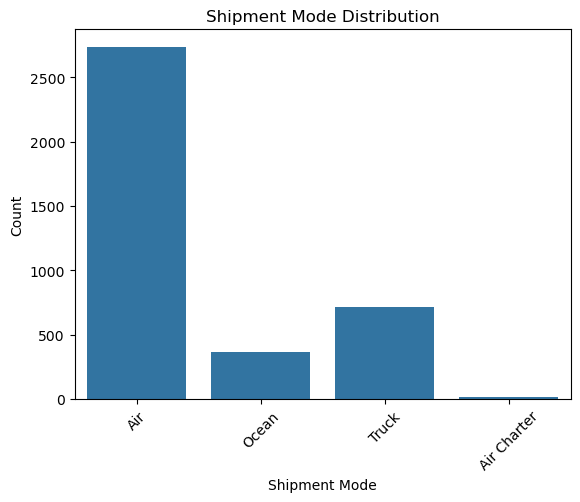

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='shipment_mode', data=df)

plt.title("Shipment Mode Distribution")
plt.xlabel("Shipment Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A countplot was chosen because Shipment Mode is a categorical variable, and this chart effectively shows the frequency of each category.

It helps in comparing how often each shipment mode (Air, Truck, Air Charter, Ocean) is used and provides a clear understanding of distribution.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Air shipment is the most frequently used mode, followed by Truck.

Air Charter and Ocean shipments are used significantly less compared to Air and Truck.

This indicates a strong preference for faster shipment methods in the supply chain.Univariate Analysis (1 variable)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [50]:
#Yes, these insights can create a positive business impact.

#By understanding that Air shipment is heavily used, the company can focus on optimizing air logistics for better efficiency.

#The business can also evaluate whether cheaper alternatives like Ocean or Truck can be used where speed is not critical, helping reduce costs.

#This enables better decision-making in selecting shipment modes based on urgency and budget.

In [51]:
#Yes, some insights may indicate potential negative impact.

#Heavy reliance on Air shipment, which is generally more expensive, can increase overall logistics costs.

#Underutilization of cost-effective modes like Ocean may indicate inefficiency in cost optimization.

#If not managed properly, this can reduce profit margins and increase operational expenses.

#### Chart - 8 Monthly On-Time Delivery Trend

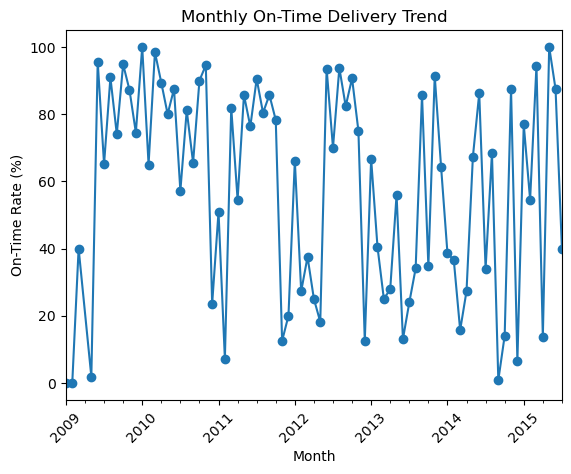

In [141]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to datetime
df['pq_first_sent_to_client_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'], errors='coerce'
)

# Create Month column
df['month'] = df['pq_first_sent_to_client_date'].dt.to_period('M')

# Calculate monthly on-time rate
monthly_ontime = df.groupby('month')['on_time_delivery'].mean() * 100

# Plot
monthly_ontime.plot(kind='line', marker='o')

plt.title("Monthly On-Time Delivery Trend")
plt.xlabel("Month")
plt.ylabel("On-Time Rate (%)")
plt.xticks(rotation=45)

plt.show()


##### 1. Why did you pick the specific chart?

A line chart was chosen because it is best suited for analyzing trends over time.

Since the data is grouped monthly, the line chart clearly shows how on-time delivery performance changes across different months and helps in identifying patterns, improvements, or fluctuations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that on-time delivery performance generally improves over time, with most values staying between 70% and 100%.

There are fluctuations in certain periods where the on-time rate drops, indicating temporary inefficiencies or operational issues.

Overall, the trend appears to stabilize at a higher performance level in later periods, suggesting improvement in delivery operations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
Yes, these insights can create a positive business impact.

By analyzing the trend, the company can identify periods of poor performance and take corrective actions.

The improving trend indicates that process optimizations are working, and these strategies can be continued or enhanced.

This helps in maintaining high delivery performance, improving customer satisfaction, and strengthening operational efficiency.

Yes, the fluctuations and occasional drops in on-time delivery indicate inconsistencies in operations.

Periods where the on-time rate decreases suggest delays, which can negatively impact customer satisfaction.

If these fluctuations are not addressed, they may lead to reduced reliability and loss of customer trust, affecting business growth.

#### Chart - 9

In [43]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10“Average Lead Time by Country

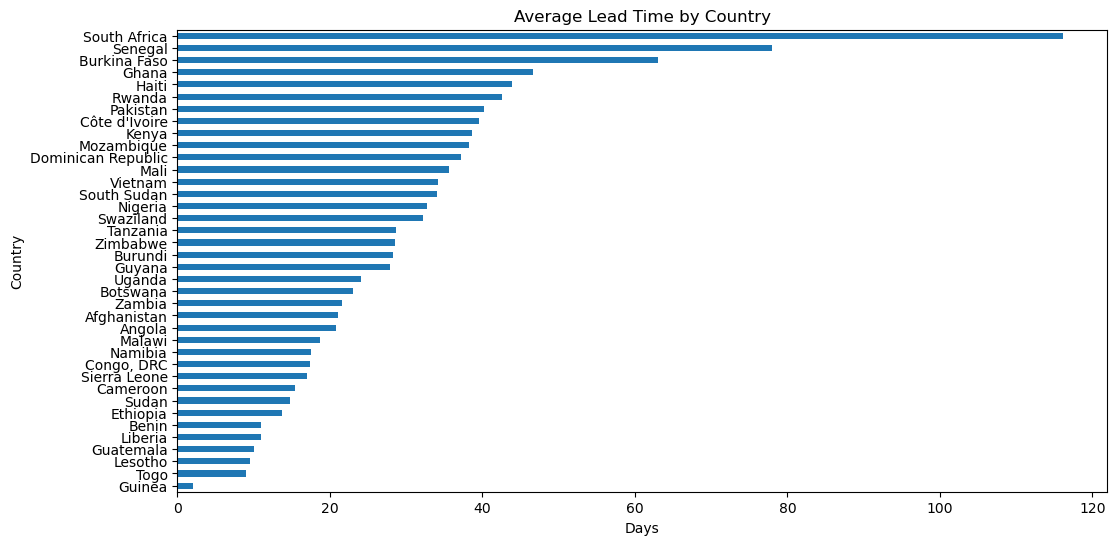

In [80]:
plt.figure(figsize=(12,6))
df.groupby('country')['lead_time'].mean().sort_values().plot(kind='barh')

plt.title("Average Lead Time by Country")
plt.xlabel("Days")
plt.ylabel("Country")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.I selected a horizontal bar chart because:

It is best suited for comparing values across categories (countries)
It clearly shows differences in lead time between countries

##### 2. What is/are the insight(s) found from the chart?

Answer Here ow Lead Time (Efficient Countries)
Guinea (~2 days)
Togo (~9 days)
Lesotho (~9.5 days)
 These countries have efficient supply chain operations There is a huge variation in lead time across countries,
which shows inconsistency in supply chain performance

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
yes,These insights help to:

Identify high-delay countries → focus improvement efforts
Optimize logistics and vendor management
Reduce delivery time → improve customer satisfaction
Improve overall supply chain efficiency

Answer HereYes, there are negative indicators:

❌ High Lead Time Countries
South Africa (116 days)
Senegal (78 days)
Burkina Faso (63 days)

👉 Reasons:

Poor logistics infrastructure
Vendor delays
Inefficient processes
Possible regulatory/custom delays

#### Chart - 11 Vendor Performance

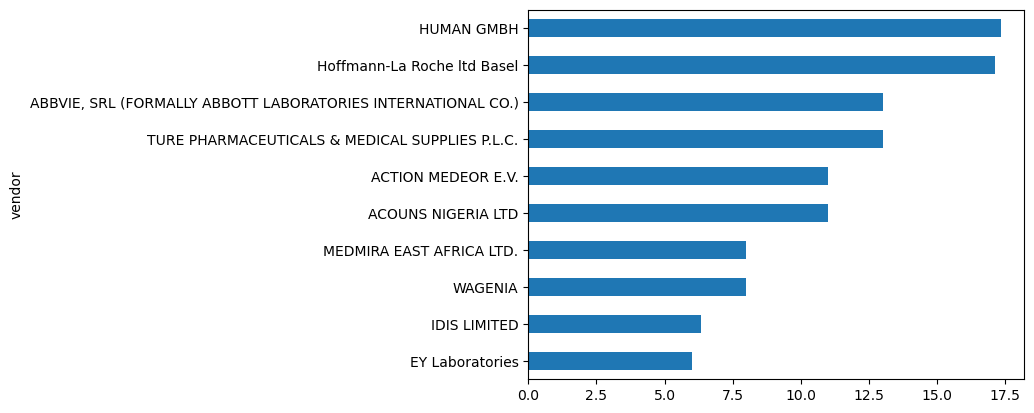

In [147]:
# Chart - 11 visualization code
df.groupby('vendor')['lead_time'].mean().sort_values().head(10).plot(kind='barh')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12 High Cost but Slow Delivery

In [151]:
# Chart - 12 visualization code
# High cost + slow delivery
inefficient = df[(df['freight_cost_(usd)'] > df['freight_cost_(usd)'].quantile(0.75)) &
                 (df['lead_time'] > df['lead_time'].quantile(0.75))]

inefficient.head()

,id,project_code,pq_#,po_/_so_#,asn/dn_#,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,pq_first_sent_to_client_date,po_sent_to_vendor_date,product_group,sub_classification,vendor,item_description,molecule/test_type,brand,dosage,dosage_form,unit_of_measure_(per_pack),line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_(kilograms),freight_cost_(usd),line_item_insurance_(usd),lead_time,delivery_days,shipment_date,order_date,on_time_delivery,freight_per_kg,late,month
2747,14018,106-HT-T30,FPQ-14895,SCMS-261060,ASN-30093,Haiti,PMO - US,Direct Drop,EXW,Air,2014-09-24,2014-11-14,ARV,Adult,HETERO LABS LIMITED,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,50544,334095.84,6.61,0.11,"Hetero, Jadcherla, unit 5, IN",Yes,4669.0,34778.32,343.45,51.0,51.0,2014-09-24,2014-11-14,0,7.448773,True,2014-09
2830,15460,106-HT-T30,FPQ-15038,SCMS-262980,ASN-30463,Haiti,PMO - US,Direct Drop,EXW,Ocean,2014-10-22,2015-01-07,ARV,Adult,HETERO LABS LIMITED,Lamivudine/Tenofovir Disoproxil Fumarate 300/3...,Lamivudine/Tenofovir Disoproxil Fumarate,Generic,300/300mg,Tablet - FDC,30,36831,170159.22,4.62,0.15,Hetero Unit III Hyderabad IN,Yes,17826.0,20526.23,174.92,77.0,77.0,2014-10-22,2015-01-07,0,1.151477,True,2014-10
2835,15625,111-MZ-T30,FPQ-14294,SCMS-247360,ASN-27766,Mozambique,PMO - US,Direct Drop,EXW,Air,2014-05-15,2014-07-30,HRDT,HIV test,"Orgenics, Ltd","HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,4708,376640.00,80.00,0.80,"Alere Medical Co., Ltd.",Yes,1914.0,13489.96,387.19,76.0,76.0,2014-05-15,2014-07-30,0,7.048046,True,2014-05
2842,15726,107-RW-T30,FPQ-9168,SCMS-137552,ASN-15729,Rwanda,PMO - US,Direct Drop,EXW,Air,2012-01-13,2012-05-31,ARV,Adult,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,"Abacavir 300mg, tablets, 60 Tabs",Abacavir,Generic,300mg,Tablet,60,46530,581159.70,12.49,0.21,Mylan (formerly Matrix) Nashik,Yes,4810.0,27894.81,814.79,139.0,139.0,2012-01-13,2012-05-31,0,5.799337,True,2012-01
2869,16098,106-HT-T30,FPQ-15038,SCMS-262840,ASN-31820,Haiti,PMO - US,Direct Drop,EXW,Ocean,2014-10-22,2014-12-24,ARV,Pediatric,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,"Abacavir/Lamivudine 60/30mg, tablets, 60 Tabs",Abacavir/Lamivudine,Generic,60/30mg,Tablet - FDC,60,3300,13035.00,3.95,0.07,Mylan (formerly Matrix) Nashik,Yes,16350.0,16028.78,13.40,63.0,63.0,2014-10-22,2014-12-24,0,0.980354,True,2014-10


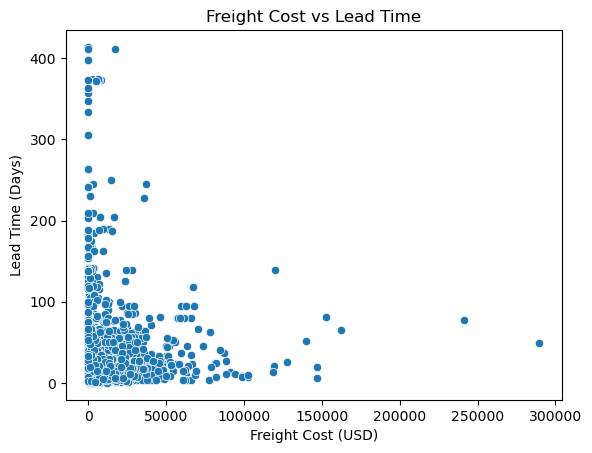

In [152]:
sns.scatterplot(x='freight_cost_(usd)', y='lead_time', data=df)

plt.title("Freight Cost vs Lead Time")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Lead Time (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer HereHigh cost but slow delivery refers to situations where shipments incur high freight costs but still take longer time to deliver.

Ideally, higher cost should result in faster delivery (premium service), but when this does not happen, it indicates inefficiency in logistics operations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer HereThis insight helps in identifying cost inefficiencies and improving logistics strategy. The company can optimize shipment modes, select better vendors, and reduce unnecessary expenses while maintaining delivery performance.

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [137]:
df['freight_per_kg'] = df['freight_cost_(usd)'] / df['weight_(kilograms)']

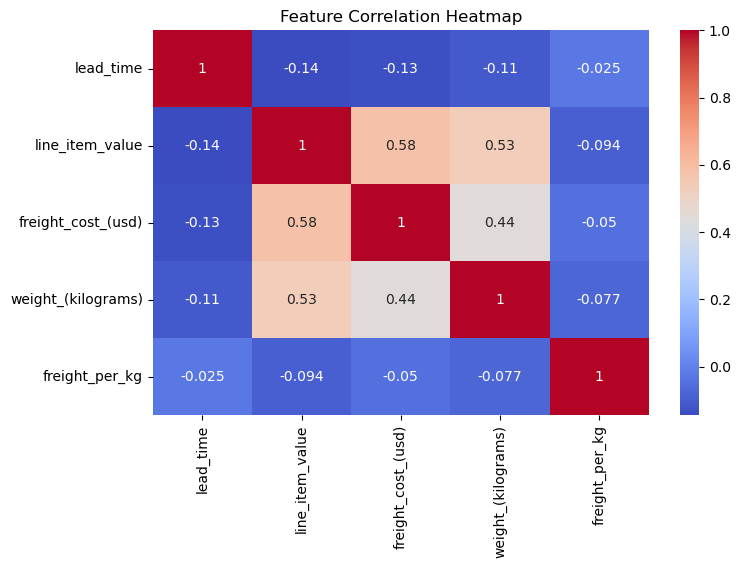

In [138]:
# Correlation Heatmap visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select required columns
num_df = df[['lead_time', 'line_item_value', 
             'freight_cost_(usd)', 'weight_(kilograms)', 
             'freight_per_kg']]

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.A correlation heatmap was chosen to understand the relationships between multiple numerical variables at once. It provides a clear visual representation of how strongly variables like lead time, freight cost, weight, and item value are related to each other.

##### 2. What is/are the insight(s) found from the chart?

Answer Here The heatmap reveals several important insights:

- There is a strong positive correlation between line_item_value and freight_cost_(usd) (0.58), indicating that higher value items tend to have higher shipping costs.

- Weight also shows a moderate positive correlation with freight_cost_(usd) (0.44), meaning heavier shipments generally cost more.

- Line_item_value and weight are also moderately correlated (0.53), suggesting that higher value items are often heavier.

- Lead_time has very weak negative correlations with other variables (around -0.1), indicating that delivery time is not strongly influenced by cost, weight, or item value.

- Freight_per_kg has very weak correlation with all variables, showing inconsistency in cost efficiency across shipments.

#### Chart - 15 - Pair Plot

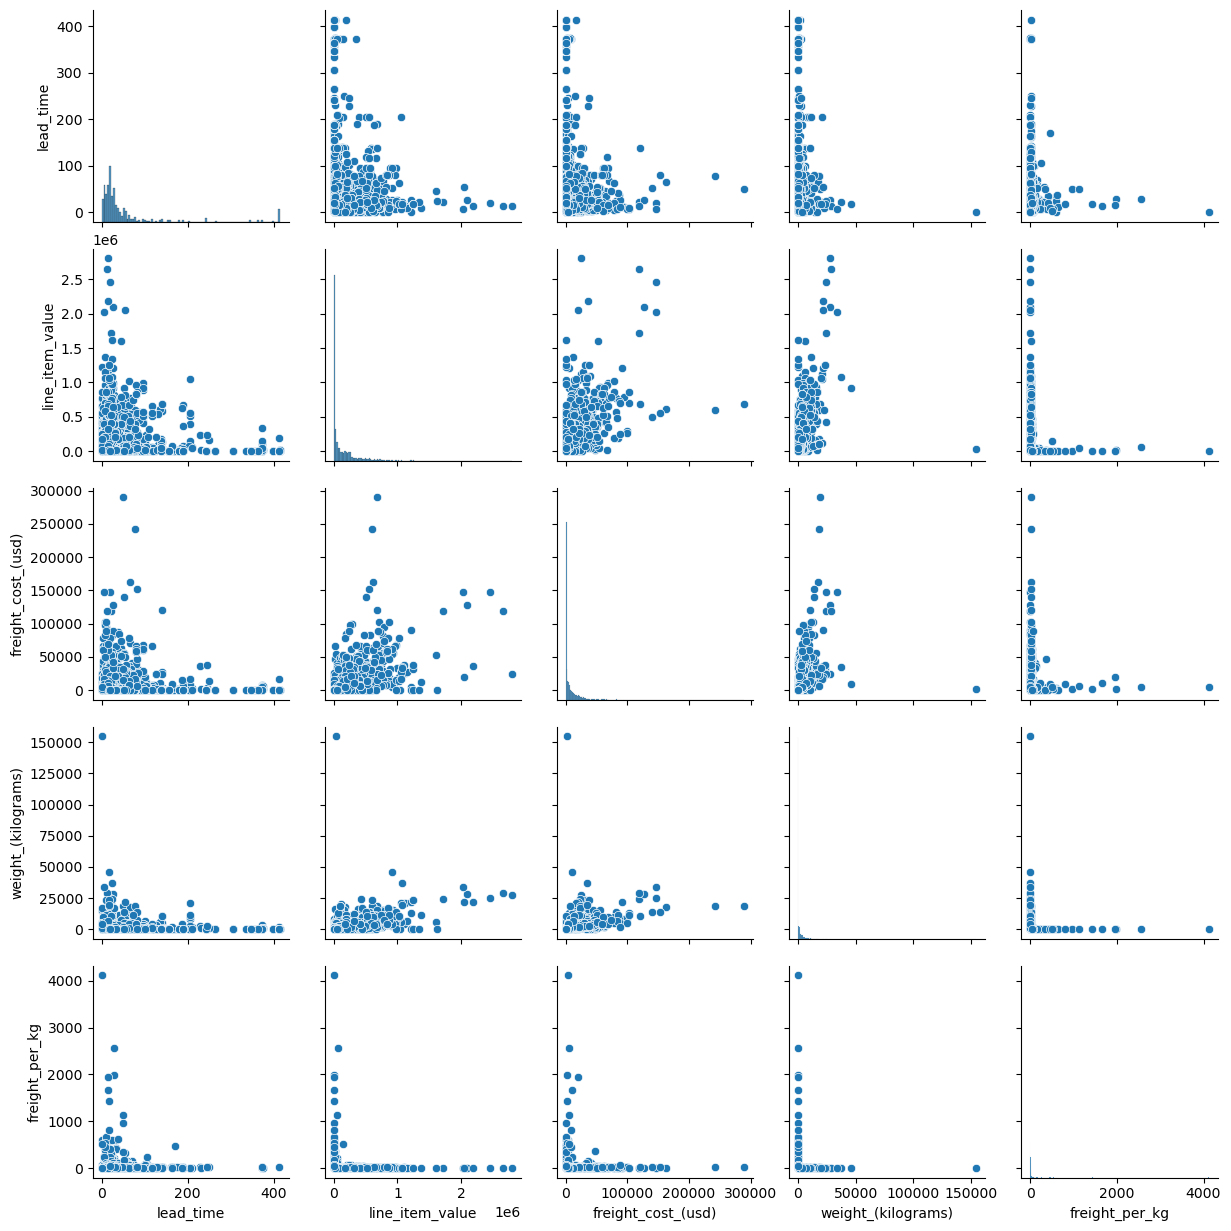

In [140]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select important columns
pair_df = df[['lead_time', 'line_item_value', 
              'freight_cost_(usd)', 'weight_(kilograms)', 
              'freight_per_kg']]

sns.pairplot(pair_df)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.pair plot to understand relationships between multiple numerical variables simultaneously

##### 2. What is/are the insight(s) found from the chart?

Answer Here Freight cost increases with weight → positive relationship
- Line item value and freight cost are related
- Lead time shows weak relation with other variables
- Some scatter plots show wide spread → variability
- Diagonal plots show distribution of each variable

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***